In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Data Sources:


*   'Happiness' Scores Datasets 2015, 2016, 2017, 2018, 2019
*   Net Migration Information 1960-2024 Every Year
*   Religious Composition: 2010, 2020
*   Global Info:



In [2]:
global_info_long = pd.read_csv("global_info_2010_2020.csv")
global_info_long.rename(columns = {"Country Name": "Country", "2010 [YR2010]":"Yr2010", "2020 [YR2020]":"Yr2020"}, inplace = True)
global_info_long.dropna(inplace = True)

In [3]:
global_info_long.sort_values('Country')

,Country,Country Code,Series Name,Series Code,Yr2010,Yr2020
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,42.7,97.7
28,Afghanistan,AFG,Net migration,SM.POP.NETM,-167460,143634
29,Afghanistan,AFG,Net official aid received (constant 2021 US$),DT.ODA.OATL.KD,..,..
30,Afghanistan,AFG,"Net primary income (BoP, current US$)",BN.GSR.FCTY.CD,27931206.5193244,189227088.699124
31,Afghanistan,AFG,"Physicians (per 1,000 people)",SH.MED.PHYS.ZS,0.245,0.254
...,...,...,...,...,...,...
10067,Zimbabwe,ZWE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,51.925,61.53
10068,Zimbabwe,ZWE,Manufactures exports (% of merchandise exports),TX.VAL.MANF.ZS.UN,18.7610356207287,7.9320260228422
10069,Zimbabwe,ZWE,Manufactures imports (% of merchandise imports),TM.VAL.MANF.ZS.UN,62.0010170126759,57.8261465284639
10071,Zimbabwe,ZWE,Military expenditure (current LCU),MS.MIL.XPND.CN,98293000,11866800000


In [4]:
global_info_long.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10093    False
10094    False
10095    False
10096    False
10097    False
Length: 10098, dtype: bool

In [5]:
global_2010 = global_info_long.pivot(index = "Country", columns = "Series Name", values = "Yr2010")
global_2010['Year'] = 2010
global_2020 = global_info_long.pivot(index = "Country", columns = "Series Name", values = "Yr2020")
global_2020['Year'] = 2020

In [6]:
global_2010.head()
global_2010.describe(include = "all")

Series Name,Access to electricity (% of population),Adjusted savings: net forest depletion (% of GNI),Agricultural land (% of land area),Arms imports (SIPRI trend indicator values),Average precipitation in depth (mm per year),Current health expenditure (% of GDP),Forcibly displaced people,Forest area (% of land area),Government Effectiveness: Estimate,Gross national expenditure (% of GDP),...,"Taxes on income, profits and capital gains (% of revenue)",Taxes on international trade (% of revenue),"Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)","Unemployment, youth total (% of total labor force ages 15-24) (national estimate)",Urban population (% of total population),Urban population growth (annual %),"Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Year
count,198,198,198,198,198,198,198,198,198,198,...,198,198,198,198,198,198,198,198,198,198.0
unique,114,103,195,91,173,190,159,194,193,164,...,124,107,181,127,182,115,193,198,182,NaN
top,100,0,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,100,3.81906849382784,..,NaN
freq,58,78,4,79,20,9,35,3,5,35,...,74,92,17,71,17,84,5,1,17,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0


In [7]:
global_2010.value_counts()

Access to electricity (% of population)  Adjusted savings: net forest depletion (% of GNI)  Agricultural land (% of land area)  Arms imports (SIPRI trend indicator values)  Average precipitation in depth (mm per year)  Current health expenditure (% of GDP)  Forcibly displaced people  Forest area (% of land area)  Government Effectiveness: Estimate  Gross national expenditure (% of GDP)  Imports of goods and services (% of GDP)  Inflation, consumer prices (annual %)  Intentional homicides (per 100,000 people)  International migrant stock (% of population)  International tourism, number of arrivals  Labor force, female (% of total labor force)  Labor force, total  Land area (sq. km)  Life expectancy at birth, female (years)  Life expectancy at birth, male (years)  Life expectancy at birth, total (years)  Manufactures exports (% of merchandise exports)  Manufactures imports (% of merchandise imports)  Manufacturing, value added (% of GDP)  Military expenditure (current LCU)  Military expe

In [8]:
global_2020.describe()

Series Name,Year
count,198.0
mean,2020.0
std,0.0
min,2020.0
25%,2020.0
50%,2020.0
75%,2020.0
max,2020.0


In [9]:
happy_2015 = pd.read_csv("2015.csv")
happy_2016 = pd.read_csv("2016.csv")
happy_2017 = pd.read_csv("2017.csv")
happy_2018 = pd.read_csv("2018.csv")
happy_2019 = pd.read_csv("2019.csv")


In [10]:
happy_2015.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

In [11]:
happy_2016.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')

In [12]:
happy_2017.columns
happy_2017.rename(columns = {"Happiness.Rank": "Happiness Rank",
                             "Happiness.Score": "Happiness Score",
                             "Economy..GDP.per.Capita.": "Economy (GDP per Capita)",
                             "Health..Life.Expectancy.": "Healthy (Life Expectancy)",
                             "Trust..Government.Corruption.": "Trust (Government Corruption)",
                             "Dystopia.Residual" : "Dystopia Residual"}, inplace= True)

In [13]:
happy_2018.columns
happy_2018.rename(columns = {"Overall rank": "Happiness Rank",
                             "Country or region": "Country",
                             "Score": "Happiness Score",
                             "GDP per capita": "Economy (GDP per Capita)",
                             "Freedom to make life choices": "Freedom",
                             "Perceptions of corruption": "Trust (Government Corruption)",
                             "Healthy life expectancy": "Health (Life Expectancy)"},
                  inplace = True)

In [14]:
happy_2019.columns
happy_2019.rename(columns = {"Overall rank": "Happiness Rank",
                             "Country or region": "Country",
                             "Score": "Happiness Score",
                             "GDP per capita": "Economy (GDP per Capita)",
                             "Freedom to make life choices": "Freedom",
                             "Perceptions of corruption": "Trust (Government Corruption)",
                             "Healthy life expectancy": "Health (Life Expectancy)"},
                  inplace = True)

In [15]:
happy_2017.columns


Index(['Country', 'Happiness Rank', 'Happiness Score', 'Whisker.high',
       'Whisker.low', 'Economy (GDP per Capita)', 'Family',
       'Healthy (Life Expectancy)', 'Freedom', 'Generosity',
       'Trust (Government Corruption)', 'Dystopia Residual'],
      dtype='object')

In [16]:
happy_2015.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

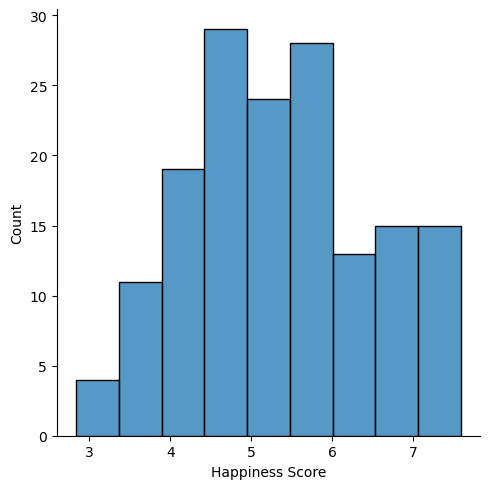

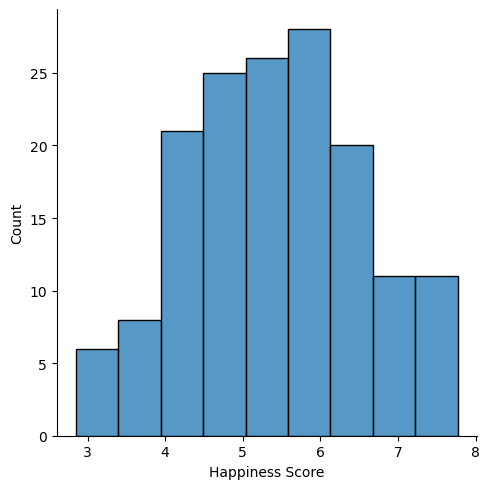

In [17]:
sns.displot(data = happy_2015, x = 'Happiness Score')
sns.displot(data = happy_2019, x = 'Happiness Score')

In [18]:
happy_full = happy_2015.merge(
    happy_2016, how = "left", on = "Country", suffixes = ('_2015', '_2016')).merge(
        happy_2017, how = "left", on = "Country", suffixes = ('', '_2017')).merge(
            happy_2018, how = "left", on = "Country", suffixes = ('', '_2018')).merge(
                happy_2019, how = "left", on = "Country", suffixes = ('', '_2019'))



In [19]:
net_mig = pd.read_csv('netm.csv')
net_mig.head(3)

net_mig.nlargest(20, '2019')['Country Name']
net_mig_long = pd.melt(net_mig, id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], var_name = "Year", value_name = "netMig")

In [20]:
# net_mig = net_mig.rename(columns=lambda x: x + '_mig' if x in [list(range(1960,2024))] else x)
net_mig.rename(columns = {"Country Name": "Country"}, inplace = True)
net_mig.drop(["Indicator Name", "Indicator Code", "Unnamed: 69"], axis = 1, inplace = True)

In [21]:
net_mig = net_mig.add_suffix("_NetMig").rename(columns = {"Country_NetMig": "Country", "Country Code_NetMig": "Country Code"})
net_mig.columns

Index(['Country', 'Country Code', '1960_NetMig', '1961_NetMig', '1962_NetMig',
       '1963_NetMig', '1964_NetMig', '1965_NetMig', '1966_NetMig',
       '1967_NetMig', '1968_NetMig', '1969_NetMig', '1970_NetMig',
       '1971_NetMig', '1972_NetMig', '1973_NetMig', '1974_NetMig',
       '1975_NetMig', '1976_NetMig', '1977_NetMig', '1978_NetMig',
       '1979_NetMig', '1980_NetMig', '1981_NetMig', '1982_NetMig',
       '1983_NetMig', '1984_NetMig', '1985_NetMig', '1986_NetMig',
       '1987_NetMig', '1988_NetMig', '1989_NetMig', '1990_NetMig',
       '1991_NetMig', '1992_NetMig', '1993_NetMig', '1994_NetMig',
       '1995_NetMig', '1996_NetMig', '1997_NetMig', '1998_NetMig',
       '1999_NetMig', '2000_NetMig', '2001_NetMig', '2002_NetMig',
       '2003_NetMig', '2004_NetMig', '2005_NetMig', '2006_NetMig',
       '2007_NetMig', '2008_NetMig', '2009_NetMig', '2010_NetMig',
       '2011_NetMig', '2012_NetMig', '2013_NetMig', '2014_NetMig',
       '2015_NetMig', '2016_NetMig', '2017_NetMig'

In [22]:
rel_comp = pd.read_csv('relcomp.csv')
rel_comp[rel_comp['Country']=="United States"]

,Region,Country,Year,Population,Christians,Muslims,Religiously_unaffiliated,Buddhists,Hindus,Jews,Other_religions,Level,Countrycode
396,North America,United States,2010,311062790.0,78.278938,0.891187,16.454805,1.152083,0.575295,1.834127,0.813565,1,840
397,North America,United States,2020,339436158.5,64.010002,1.192381,29.730000,1.291746,0.894286,1.689206,1.192381,1,840


In [23]:
happy_full[happy_full['Country'] == "United States"]

,Country,Region_2015,Happiness Rank_2015,Happiness Score_2015,Standard Error,Economy (GDP per Capita)_2015,Family_2015,Health (Life Expectancy)_2015,Freedom_2015,Trust (Government Corruption)_2015,...,Generosity_2018,Trust (Government Corruption)_2018,Happiness Rank_2019,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
14,United States,North America,15,7.119,0.03839,1.39451,1.24711,0.86179,0.54604,0.1589,...,0.291,0.133,19.0,6.892,1.433,1.457,0.874,0.454,0.28,0.128


In [24]:
global_info = pd.read_csv("world-data-2023.csv")
global_info.head(3)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626


In [25]:
# "Cote D'Ivoire" --> "Ivory Coast"
net_mig.loc[net_mig['Country'] == "Cote d'Ivoire",'Country'] = "Ivory Coast"
# "Iran, Islamic Rep." --> "Iran"
net_mig.loc[net_mig['Country'] == "Iran, Islamic Rep.",'Country'] = "Iran"
#  "Korea, Dem. People's Rep." --> "North Korea"
net_mig.loc[net_mig['Country'] == "Korea, Dem. People's Rep.",'Country'] = "North Korea"
# "Korea, Rep." --> "South Korea"
net_mig.loc[net_mig['Country'] == "Korea, Rep.",'Country'] = "South Korea"
#  "Kyrgyz Republic" --> "Kyrgyzstan"
net_mig.loc[net_mig['Country'] == "Kyrgyz Republic",'Country'] = "Kyrgyzstan"
# "Lao PDR" --> "Laos"
net_mig.loc[net_mig['Country'] == "Lao PDR",'Country'] = "Laos"
# "North Macedonia" --> "Macedonia"
net_mig.loc[net_mig['Country'] == "North Macedonia",'Country'] = "Macedonia"
# "Russian Federation" --> "Russia"
net_mig.loc[net_mig['Country'] == "Russian Federation",'Country'] = "Russia"
# 'Slovak Republic' --> "Slovakia"
net_mig.loc[net_mig['Country'] == "Slovak Republic",'Country'] = "Slovakia"
# 'Eswatini' --> "Swaziland"
net_mig.loc[net_mig['Country'] == "Eswatini",'Country'] = "Swaziland"
#  'Syrian Arab Republic' --> "Syria"
net_mig.loc[net_mig['Country'] == "Syrian Arab Republic",'Country'] = "Syria"
# 'Turkiye' --> "Turkey"
net_mig.loc[net_mig['Country'] == "Turkiye",'Country'] = "Turkey"
# 'Venezuela, RB' --> "Venezuela"
net_mig.loc[net_mig['Country'] == "Venezuela, RB",'Country'] = "Venezuela"
# 'Viet Nam' --> "Vietnam"
net_mig.loc[net_mig['Country'] == "Viet Nam",'Country'] = "Vietnam"
# 'Yemen, Rep.' --> "Yemen"
net_mig.loc[net_mig['Country'] == "Yemen, Rep.",'Country'] = "Yemen"

In [26]:
# Congo (Brazzaville) --> 'Congo, Rep.'
happy_full.loc[happy_full['Country'] == "Congo (Brazzaville)",'Country'] = "Congo, Rep."
# "Congo (Kinshasa)" -->'Congo, Dem. Rep.'
happy_full.loc[happy_full['Country'] == "Congo (Kinshasa)",'Country'] = "Congo, Dem. Rep."
# "North Cyprus" --> "Cyprus"
happy_full.loc[happy_full['Country'] == "North Cyprus",'Country'] = "Cyprus"
# "Somaliland region" --> "Somalia"
happy_full.loc[happy_full['Country'] == "Somaliland region",'Country'] = "Somalia"

In [27]:
# Bahamas, The --> The Bahamas
net_mig.loc[net_mig['Country'] == "Bahamas, The",'Country'] = "The Bahamas"
# 'Brunei Darussalam' --> Brunei
net_mig.loc[net_mig['Country'] == "Brunei Darussalam",'Country'] = "Brunei"
# 'Cabo Verde' --> 'Cape Verde']
net_mig.loc[net_mig['Country'] == "Cabo Verde",'Country'] = "Cape Verde"
# 'Egypt, Arab Rep.' --> "Egypt"
net_mig.loc[net_mig['Country'] == "Egypt, Arab Rep.",'Country'] = "Egypt"
# 'Gambia, The' --> The Gambia
net_mig.loc[net_mig['Country'] == "Gambia, The",'Country'] = "The Gambia"
# Sum up net migration across data set
net_mig["NetMigSince1960"] = net_mig.iloc[:, 2:67].apply(sum, axis = 1)

In [28]:
list(global_info.sort_values('Country')['Country'])[186:205]
#  'Democratic Republic of the Congo' -- > 'Congo, Dem. Rep.'
global_info.loc[global_info['Country'] == "Democratic Republic of the Congo",
                'Country'] = "Congo, Dem. Rep."
# Republic of the Congo --> 'Congo, Rep.'
global_info.loc[global_info['Country'] == "Republic of the Congo",
                'Country'] = "Congo, Rep."
# Czech Republic --> 'Czechia'
global_info.loc[global_info['Country'] == "Czech Republic",
                'Country'] = "Czechia"
# East Timor --> Timor-Leste
global_info.loc[global_info['Country'] == "East Timor",
                'Country'] = "Timor-Leste"
# Eswatini --> Swaziland
global_info.loc[global_info['Country'] == "Eswatini",
                'Country'] = "Swaziland"
# Federated States of Micronesia --> Micronesia
global_info.loc[global_info['Country'] == "Federated States of Micronesia",
                'Country'] = "Micronesia"
# Ireland
global_info.loc[global_info['Country'] == "Republic of Ireland",
                'Country'] = "Ireland"
# Kosovo

# Macedonia
global_info.loc[global_info['Country'] == "North Macedonia",
                'Country'] = "Macedonia"
# 'Saint Kitts and Nevis'
global_info.loc[global_info['Country'] == "Saint Kitts and Nevis",
                'Country'] = "St. Kitts and Nevis"
# 'Saint Lucia'
global_info.loc[global_info['Country'] == "Saint Lucia",
                'Country'] = "St. Lucia"
# 'Saint Vincent and the Grenadines'
global_info.loc[global_info['Country'] == "Saint Vincent and the Grenadines",
                'Country'] = "St. Vincent and the Grenadines"
# S����������� --> Sao Tome and Principe
global_info.loc[global_info['Country'] == "S�����������",
                'Country'] = "Sao Tome and Principe"

In [29]:
countries_df = global_info.merge(
    net_mig, on = "Country", how = "left").merge(
        rel_comp[rel_comp['Year'] == 2010], on = "Country", how = "left").merge(
                happy_full, on = "Country", how = "left")

countries_df.head(3)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Generosity_2018,Trust (Government Corruption)_2018,Happiness Rank_2019,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,0.191,0.036,154.0,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,0.149,0.032,107.0,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,0.055,0.135,88.0,5.211,1.002,1.160,0.785,0.086,0.073,0.114


In [30]:
countries_df_subset = countries_df[['Country', 'Density\n(P/Km2)',
 'Agricultural Land( %)', 'Land Area(Km2)','Armed Forces size','Birth Rate',
 'Calling Code','Capital/Major City','Co2-Emissions','CPI','CPI Change (%)',
 'Currency-Code','Fertility Rate','Forested Area (%)','Gasoline Price',
 'GDP','Gross primary education enrollment (%)','Gross tertiary education enrollment (%)',
 'Infant mortality','Largest city','Life expectancy','Maternal mortality ratio',
 'Minimum wage','Out of pocket health expenditure','Physicians per thousand',
 'Population_x','Population: Labor force participation (%)','Tax revenue (%)',
 'Total tax rate','Unemployment rate','Urban_population','Latitude','Longitude',
 '1960_NetMig','1970_NetMig','1980_NetMig','1990_NetMig','2000_NetMig',
 '2010_NetMig','2020_NetMig','Population_y','Christians','Muslims',
 'Religiously_unaffiliated','Buddhists','Hindus','Jews','Other_religions',
 'Happiness Rank_2015','Happiness Score_2015','Standard Error',
 'Economy (GDP per Capita)_2015','Family_2015','Health (Life Expectancy)_2015',
 'Freedom_2015','Trust (Government Corruption)_2015','Generosity_2015',
 'Dystopia Residual_2015','Happiness Rank_2019','Happiness Score_2019',
 'Economy (GDP per Capita)_2019','Social support_2019','Health (Life Expectancy)_2019',
 'Freedom_2019','Generosity_2019','Trust (Government Corruption)_2019']]

In [31]:
countries_df_subset.rename(columns = {'Population_x':'Population_2023', 'Population_y':'Population_2010'}, inplace = True)

/var/folders/h0/rz117nwn0cj2s2ts75zw05cr0000gn/T/ipykernel_41057/3766902817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df_subset.rename(columns = {'Population_x':'Population_2023', 'Population_y':'Population_2010'}, inplace = True)


In [32]:
def strnum_to_int(x):
  y = "".join(x.split(","))
  return(y)

#countries_df_subset['Population_2023'].apply(strnum_to_int)

# Check types that are float
for i in range(len(countries_df_subset['Population_2023'])):
  row = countries_df_subset['Population_2023'][i]
  row_type = type(row)
  if(isinstance(row, float)):
    print(i, row_type)

# Drop Palestinian National Authority
countries_df_subset.drop(134, inplace = True)

134 <class 'float'>


/var/folders/h0/rz117nwn0cj2s2ts75zw05cr0000gn/T/ipykernel_41057/3590105275.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df_subset.drop(134, inplace = True)


In [33]:
countries_df_subset.loc[:, 'Population_2023'] = countries_df_subset['Population_2023'].apply(strnum_to_int)

/var/folders/h0/rz117nwn0cj2s2ts75zw05cr0000gn/T/ipykernel_41057/1411077079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df_subset.loc[:, 'Population_2023'] = countries_df_subset['Population_2023'].apply(strnum_to_int)


In [34]:
countries_df_subset[['Population_2010', 'Population_2023']]

,Population_2010,Population_2023
0,28284088.5,38041754
1,2928721.5,2854191
2,36188235.5,43053054
3,NaN,77142
4,23294825.0,31825295
...,...,...
191,28813101.0,28515829
192,87455151.5,96462106
193,26754387.0,29161922
194,13965594.0,17861030


In [35]:
countries_df_subset.reset_index(inplace=True)

In [36]:
countries_df_subset.loc[:,'Population_2023'] = countries_df_subset['Population_2023'].apply(int)

/var/folders/h0/rz117nwn0cj2s2ts75zw05cr0000gn/T/ipykernel_41057/74836234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df_subset.loc[:,'Population_2023'] = countries_df_subset['Population_2023'].apply(int)
/var/folders/h0/rz117nwn0cj2s2ts75zw05cr0000gn/T/ipykernel_41057/74836234.py:1: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  countries_df_subset.loc[:,'Population_2023'] = countries_df_subset['Population_2023'].apply(int)


<Figure size 2500x1000 with 0 Axes>

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

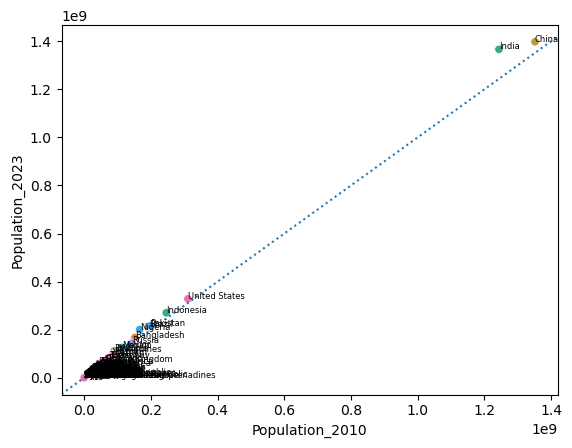

<Figure size 2500x1000 with 0 Axes>

In [182]:
sns.scatterplot(data = countries_df_subset, x = "Population_2010", y = "Population_2023", hue = "Country", legend = False)
for line in range(0, countries_df_subset.shape[0]):
       plt.text(countries_df_subset['Population_2010'][line] + 0.1, countries_df_subset.Population_2023[line], countries_df_subset.Country[line],
                horizontalalignment='left', fontsize=6, color='black')

# plt.axline(x=5, color='red', linestyle='--', label='Vertical Line')

plt.axline(xy1 = (0.0, 0.0), linestyle = ":", slope = 1)
plt.figure(figsize=(25, 10))

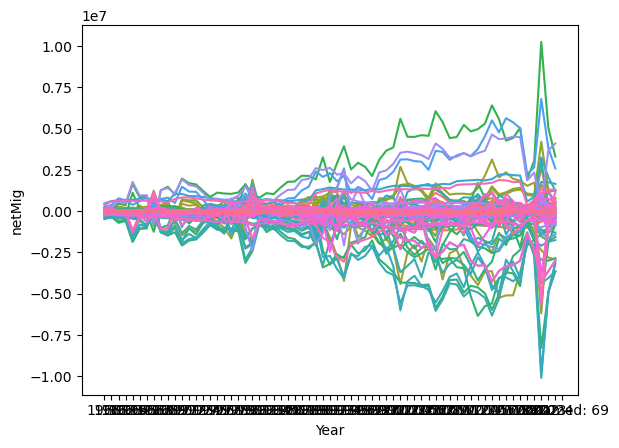

In [38]:
lplt = sns.lineplot(data=net_mig_long, x = 'Year', y='netMig',
             hue='Country Name', legend = False)
#plt.setp(lplt.get_legend().get_texts(), fontsize='2') # for legend text
plt.show()

<Axes: xlabel='Year', ylabel='netMig'>

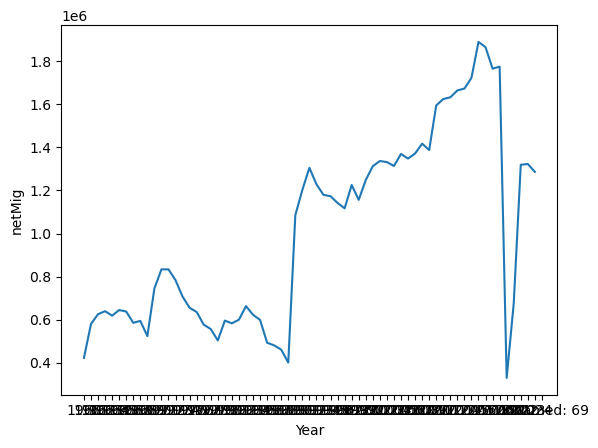

In [39]:
sns.lineplot(data= net_mig_long[net_mig_long['Country Name'] == 'United States'], x = 'Year', y='netMig',
             hue='Country Name', legend = False)

In [40]:
countries_df_subset[['Density\n(P/Km2)','Agricultural Land( %)','Land Area(Km2)','Armed Forces size','Birth Rate', 'Co2-Emissions','CPI',
                     'CPI Change (%)','Currency-Code','Fertility Rate','Forested Area (%)','Gasoline Price','GDP','Gross primary education enrollment (%)',
                     'Gross tertiary education enrollment (%)','Infant mortality', 'Life expectancy','Maternal mortality ratio','Minimum wage',
                     'Out of pocket health expenditure','Physicians per thousand','Population_2023','Population: Labor force participation (%)',
                     'Tax revenue (%)','Total tax rate','Unemployment rate','Urban_population','Latitude','Longitude','1960_NetMig','1970_NetMig',
                     '1980_NetMig','1990_NetMig','2000_NetMig','2010_NetMig','2020_NetMig','Population_2010','Christians','Muslims',
                     'Religiously_unaffiliated','Buddhists','Hindus','Jews','Other_religions','Happiness Rank_2015','Happiness Score_2015',
                     'Standard Error','Economy (GDP per Capita)_2015','Family_2015','Health (Life Expectancy)_2015','Freedom_2015',
                     'Trust (Government Corruption)_2015','Generosity_2015','Dystopia Residual_2015','Happiness Rank_2019','Happiness Score_2019',
                     'Economy (GDP per Capita)_2019','Social support_2019','Health (Life Expectancy)_2019','Freedom_2019','Generosity_2019',
                     'Trust (Government Corruption)_2019']]

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Currency-Code,Fertility Rate,...,Generosity_2015,Dystopia Residual_2015,Happiness Rank_2019,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
0,60,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,AFN,4.47,...,0.36510,1.95210,154.0,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,105,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,ALL,1.62,...,0.14272,1.89894,107.0,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,18,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,DZD,3.02,...,0.07822,2.43209,88.0,5.211,1.002,1.160,0.785,0.086,0.073,0.114
3,164,40.00%,468,NaN,7.20,469,NaN,NaN,EUR,1.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,AOA,5.52,...,0.12344,1.94939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,32,24.50%,"912,050","343,000",17.88,"164,175","2,740.27",254.90%,VED,2.27,...,0.05841,3.19131,108.0,4.707,0.960,1.427,0.805,0.154,0.064,0.047
191,314,39.30%,"331,210","522,000",16.75,"192,668",163.52,2.80%,VND,2.05,...,0.16860,2.20173,94.0,5.175,0.741,1.346,0.851,0.543,0.147,0.073
192,56,44.60%,"527,968","40,000",30.45,"10,609",157.58,8.10%,YER,3.79,...,0.09131,1.92313,151.0,3.380,0.287,1.163,0.463,0.143,0.108,0.077
193,25,32.10%,"752,618","16,000",36.19,"5,141",212.31,9.20%,ZMW,4.63,...,0.19591,2.63430,138.0,4.107,0.578,1.058,0.426,0.431,0.247,0.087


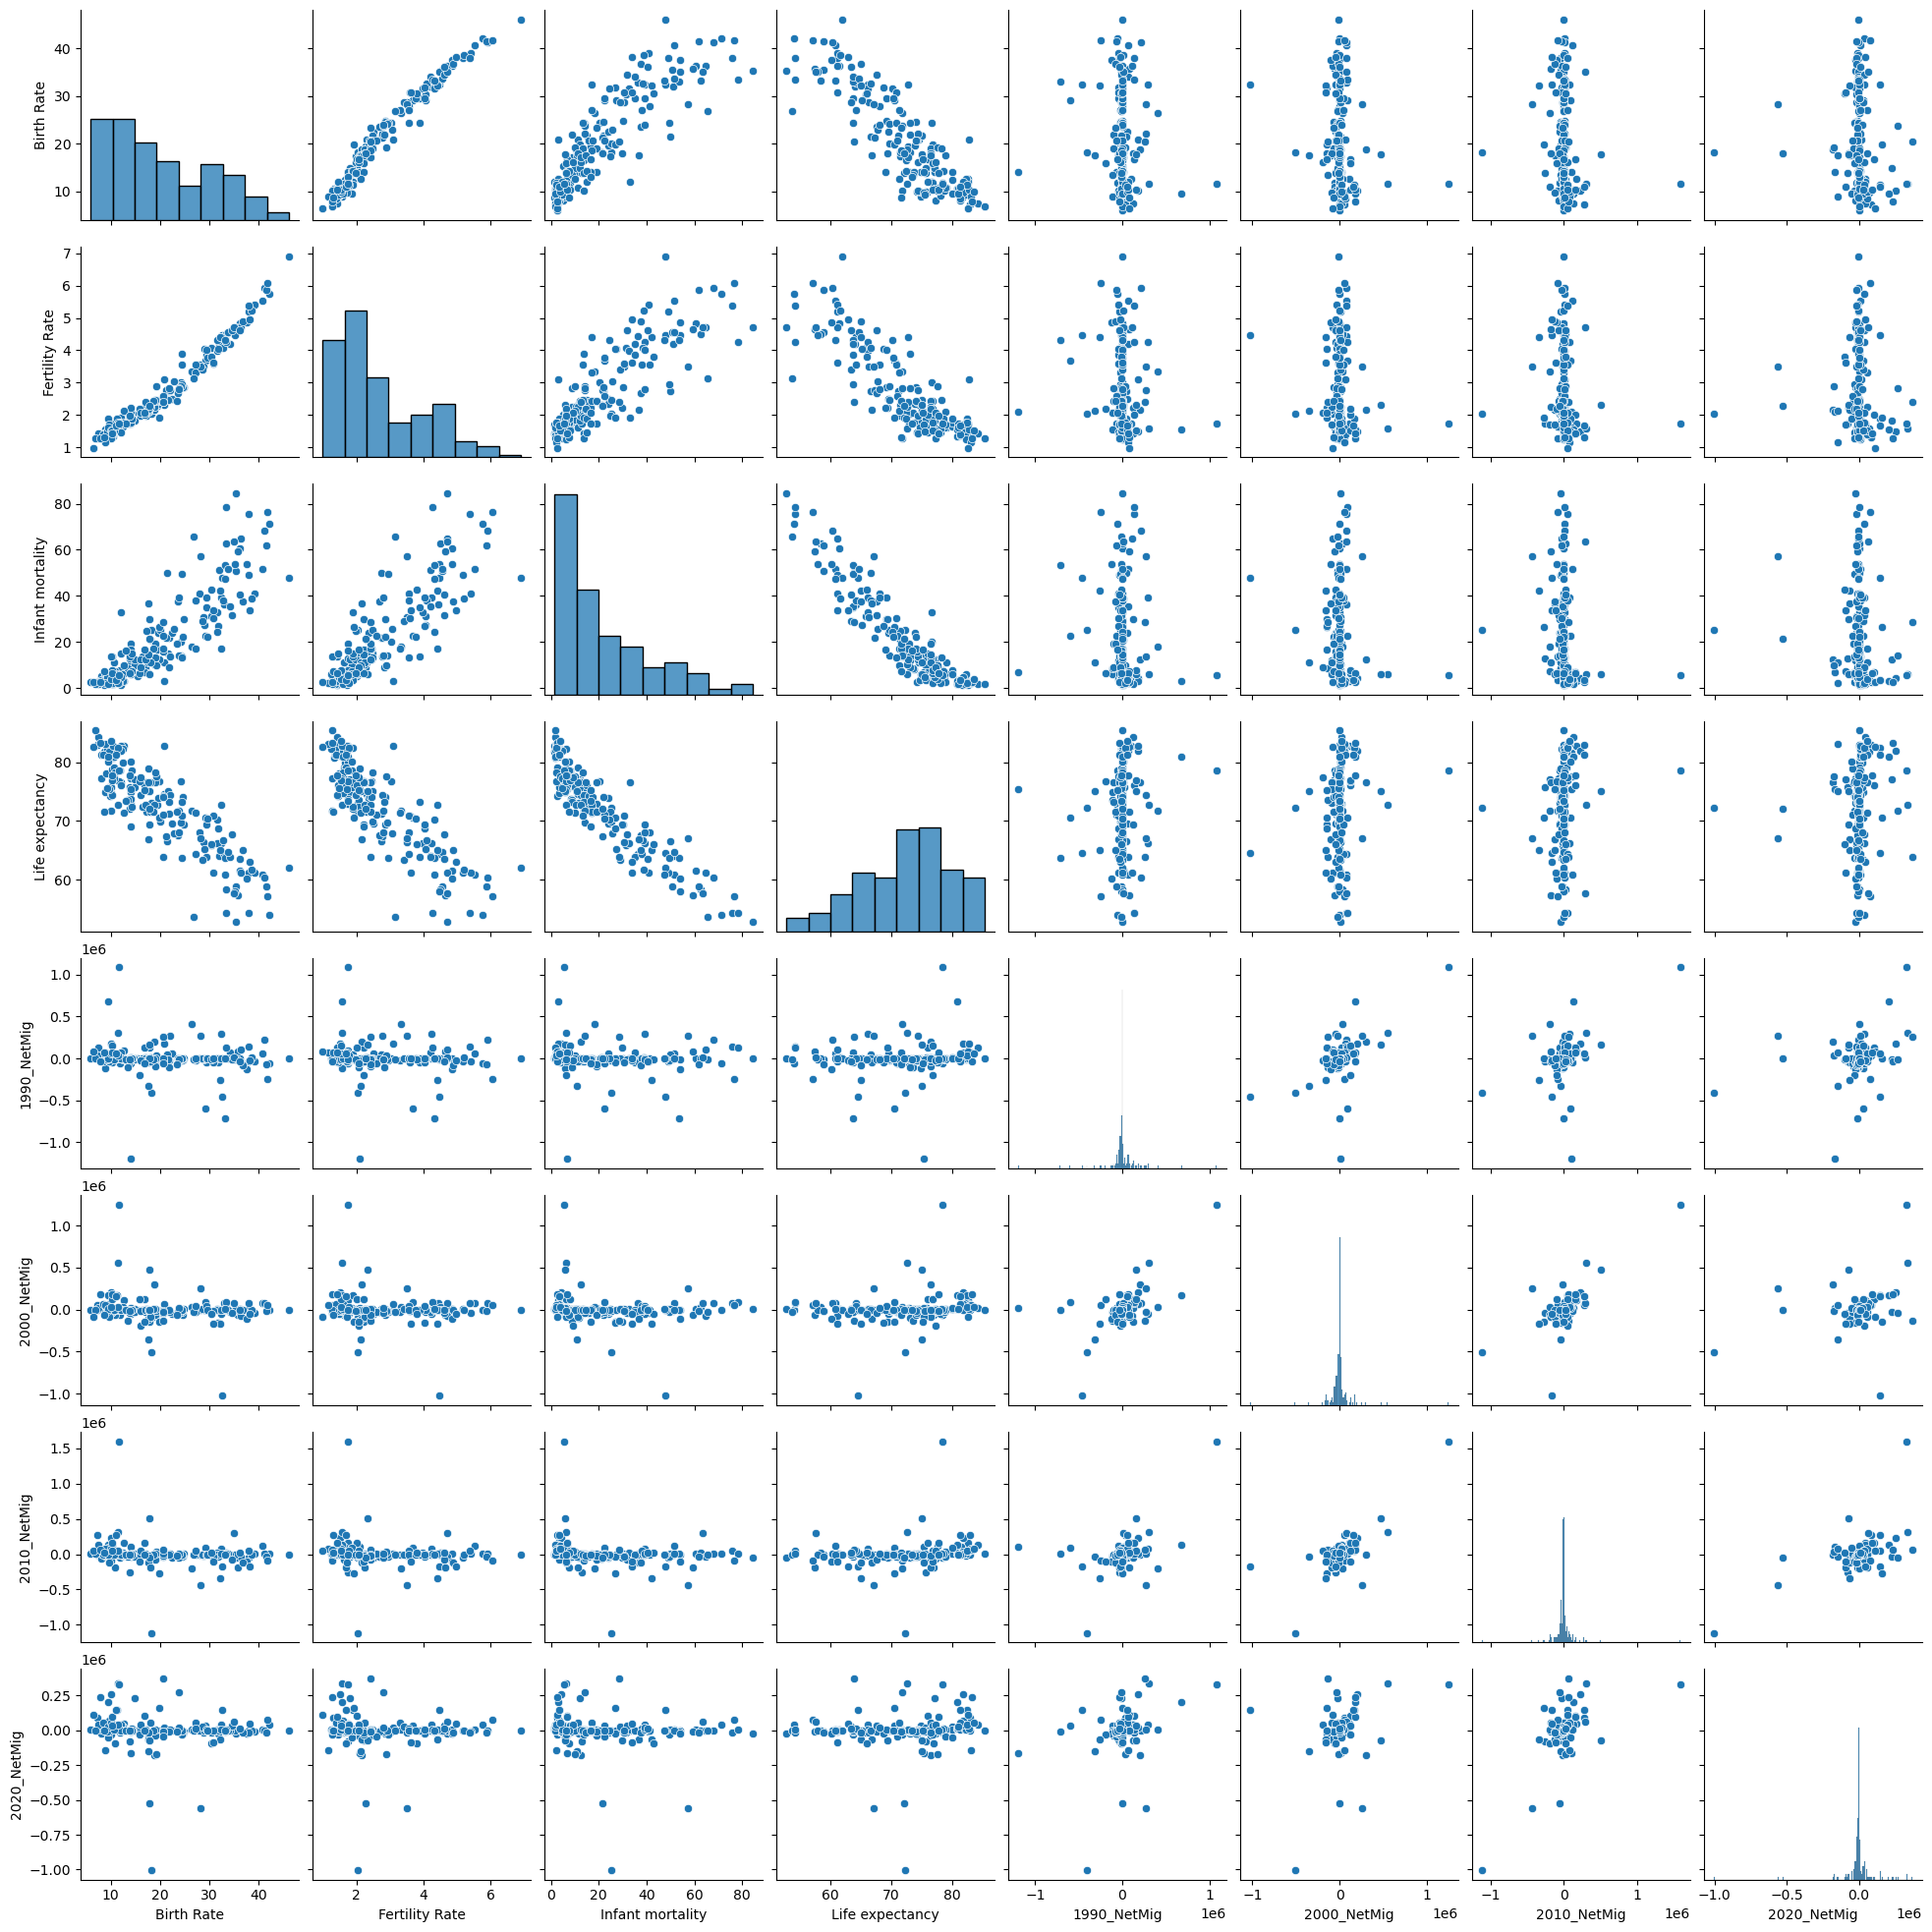

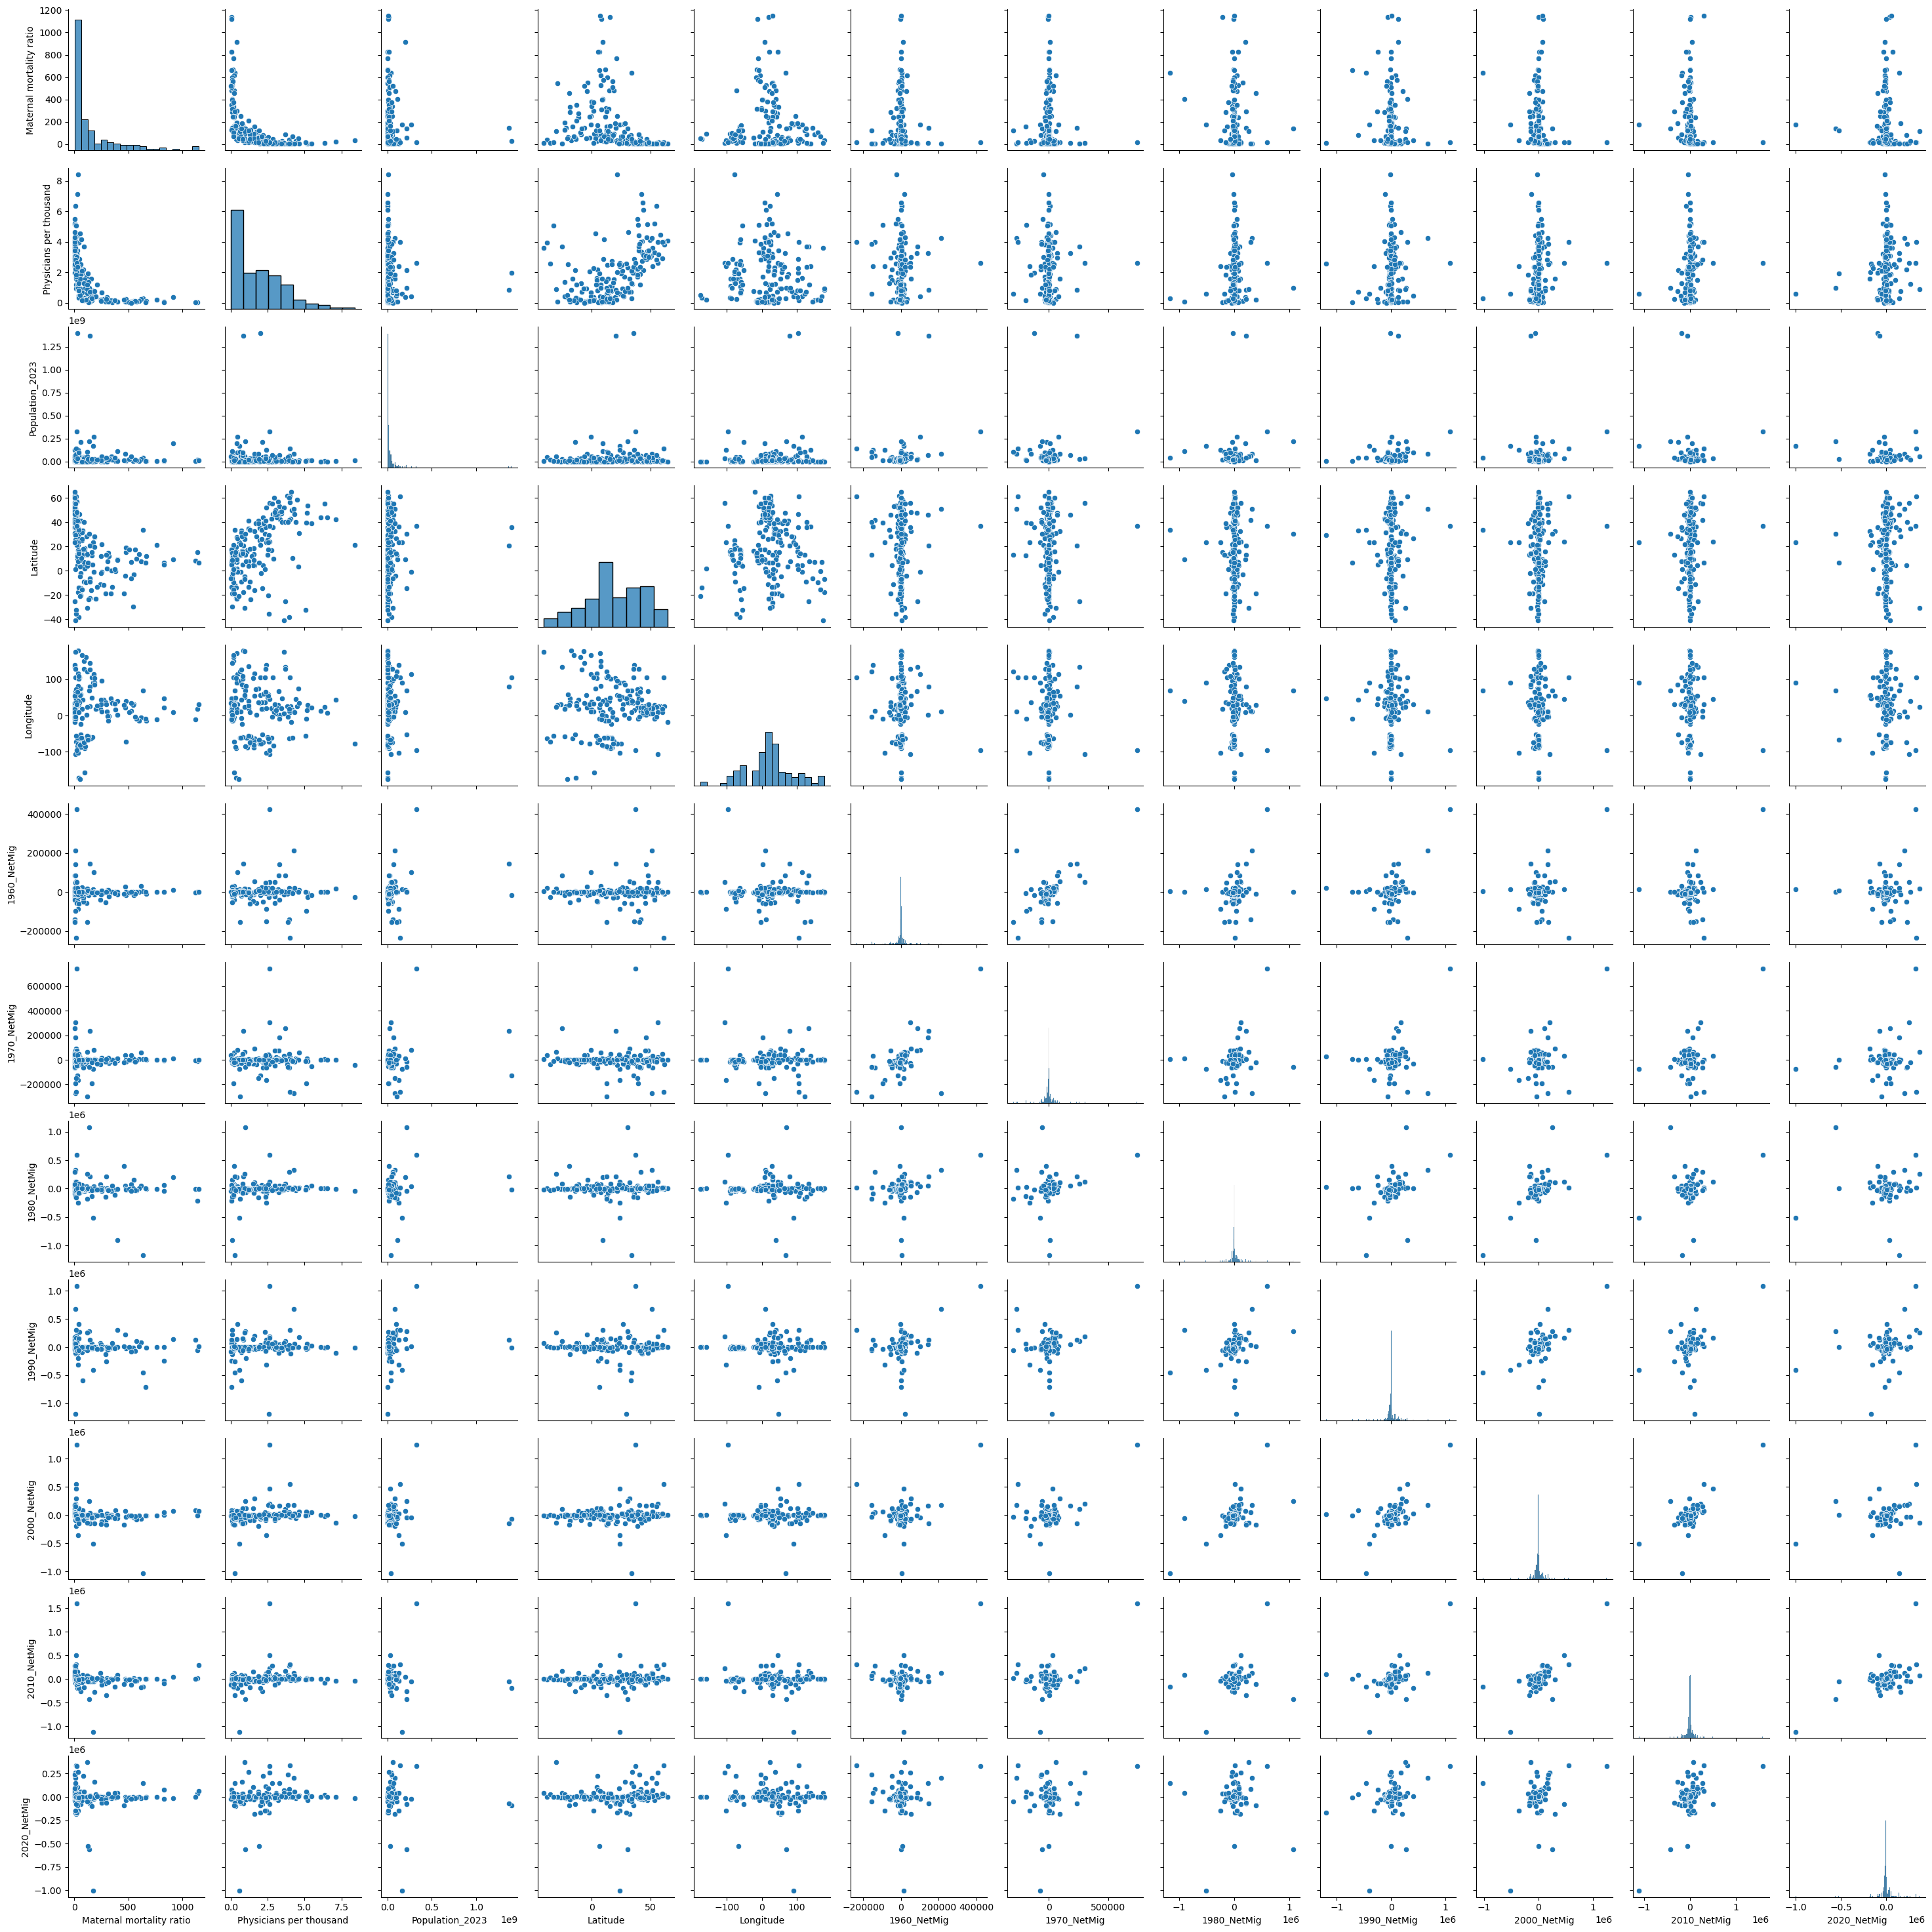

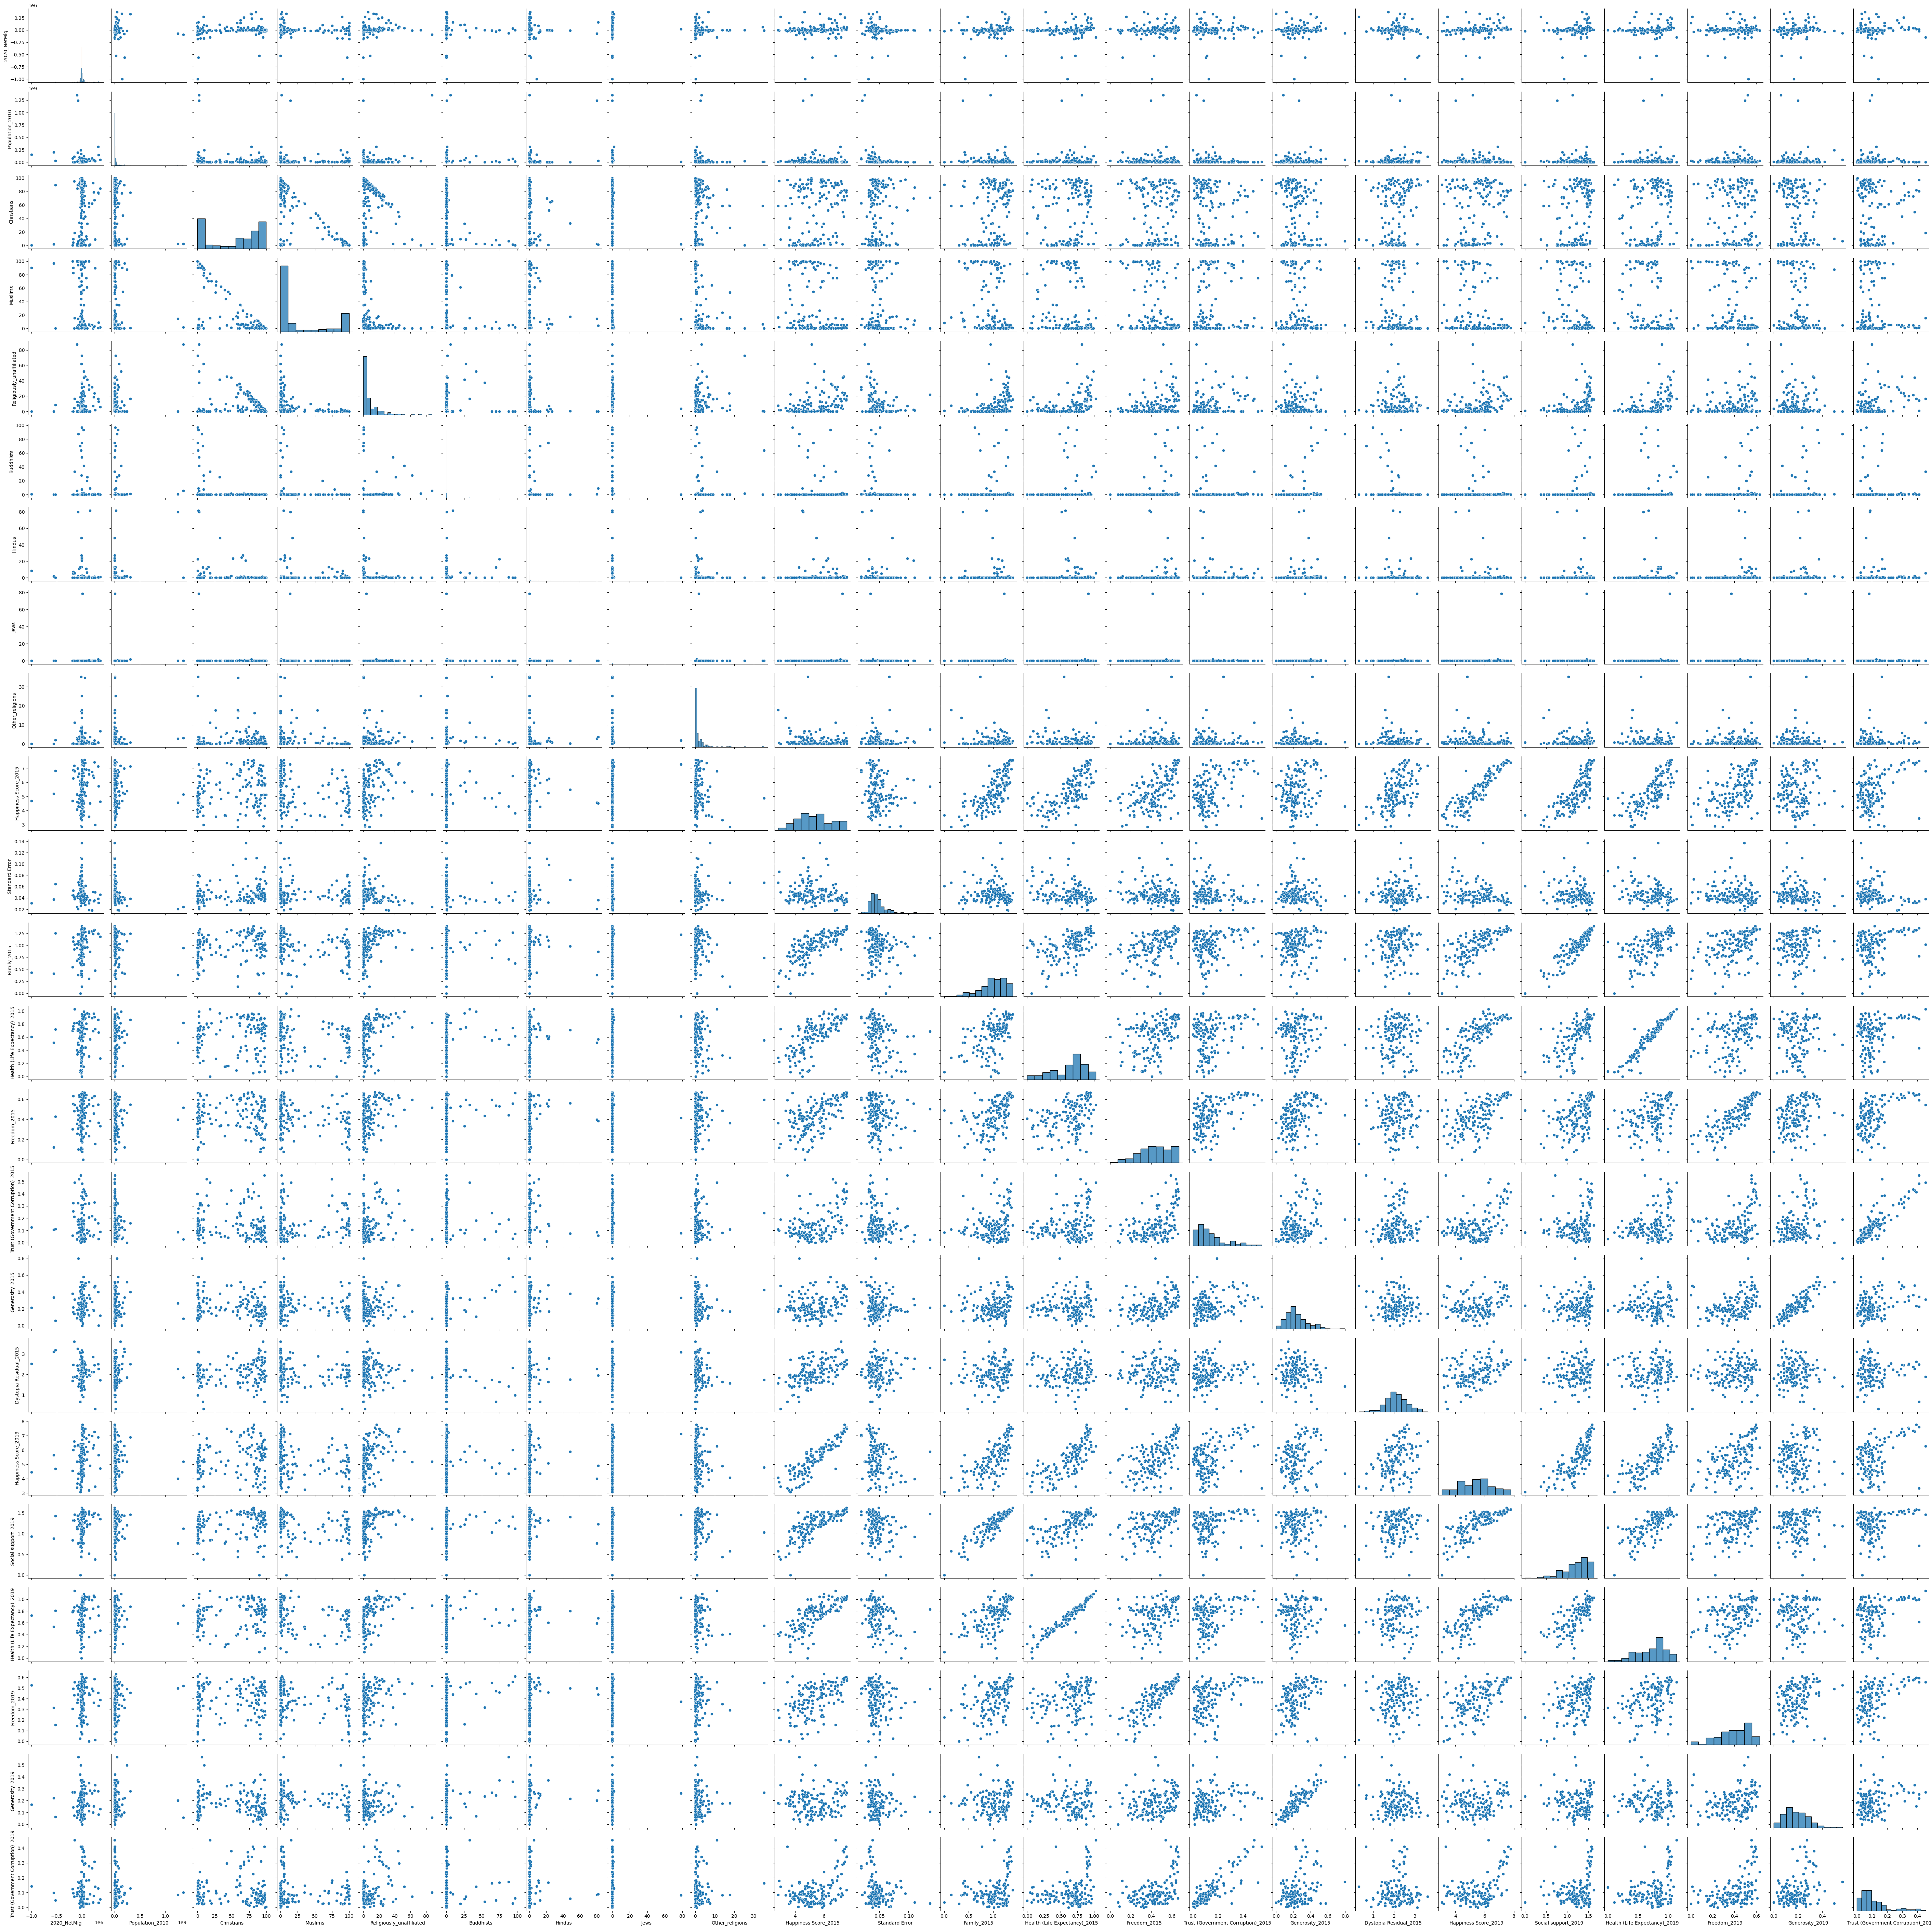

In [41]:
sns.pairplot(countries_df_subset[['Density\n(P/Km2)','Agricultural Land( %)','Land Area(Km2)','Armed Forces size','Birth Rate', 'Co2-Emissions','CPI',
                     'CPI Change (%)','Currency-Code','Fertility Rate','Forested Area (%)','Gasoline Price','GDP','Gross primary education enrollment (%)',
                     'Gross tertiary education enrollment (%)','Infant mortality', 'Life expectancy', '1990_NetMig','2000_NetMig','2010_NetMig','2020_NetMig']])

sns.pairplot(countries_df_subset[['Maternal mortality ratio','Minimum wage',
                     'Out of pocket health expenditure','Physicians per thousand','Population_2023','Population: Labor force participation (%)',
                     'Tax revenue (%)','Total tax rate','Unemployment rate','Urban_population','Latitude','Longitude','1960_NetMig','1970_NetMig',
                     '1980_NetMig','1990_NetMig','2000_NetMig','2010_NetMig','2020_NetMig']])

sns.pairplot(countries_df_subset[['2020_NetMig','Population_2010','Christians','Muslims',
                     'Religiously_unaffiliated','Buddhists','Hindus','Jews','Other_religions','Happiness Score_2015',
                     'Standard Error','Family_2015','Health (Life Expectancy)_2015','Freedom_2015',
                     'Trust (Government Corruption)_2015','Generosity_2015','Dystopia Residual_2015','Happiness Score_2019',
                     'Social support_2019','Health (Life Expectancy)_2019','Freedom_2019','Generosity_2019',
                     'Trust (Government Corruption)_2019']])


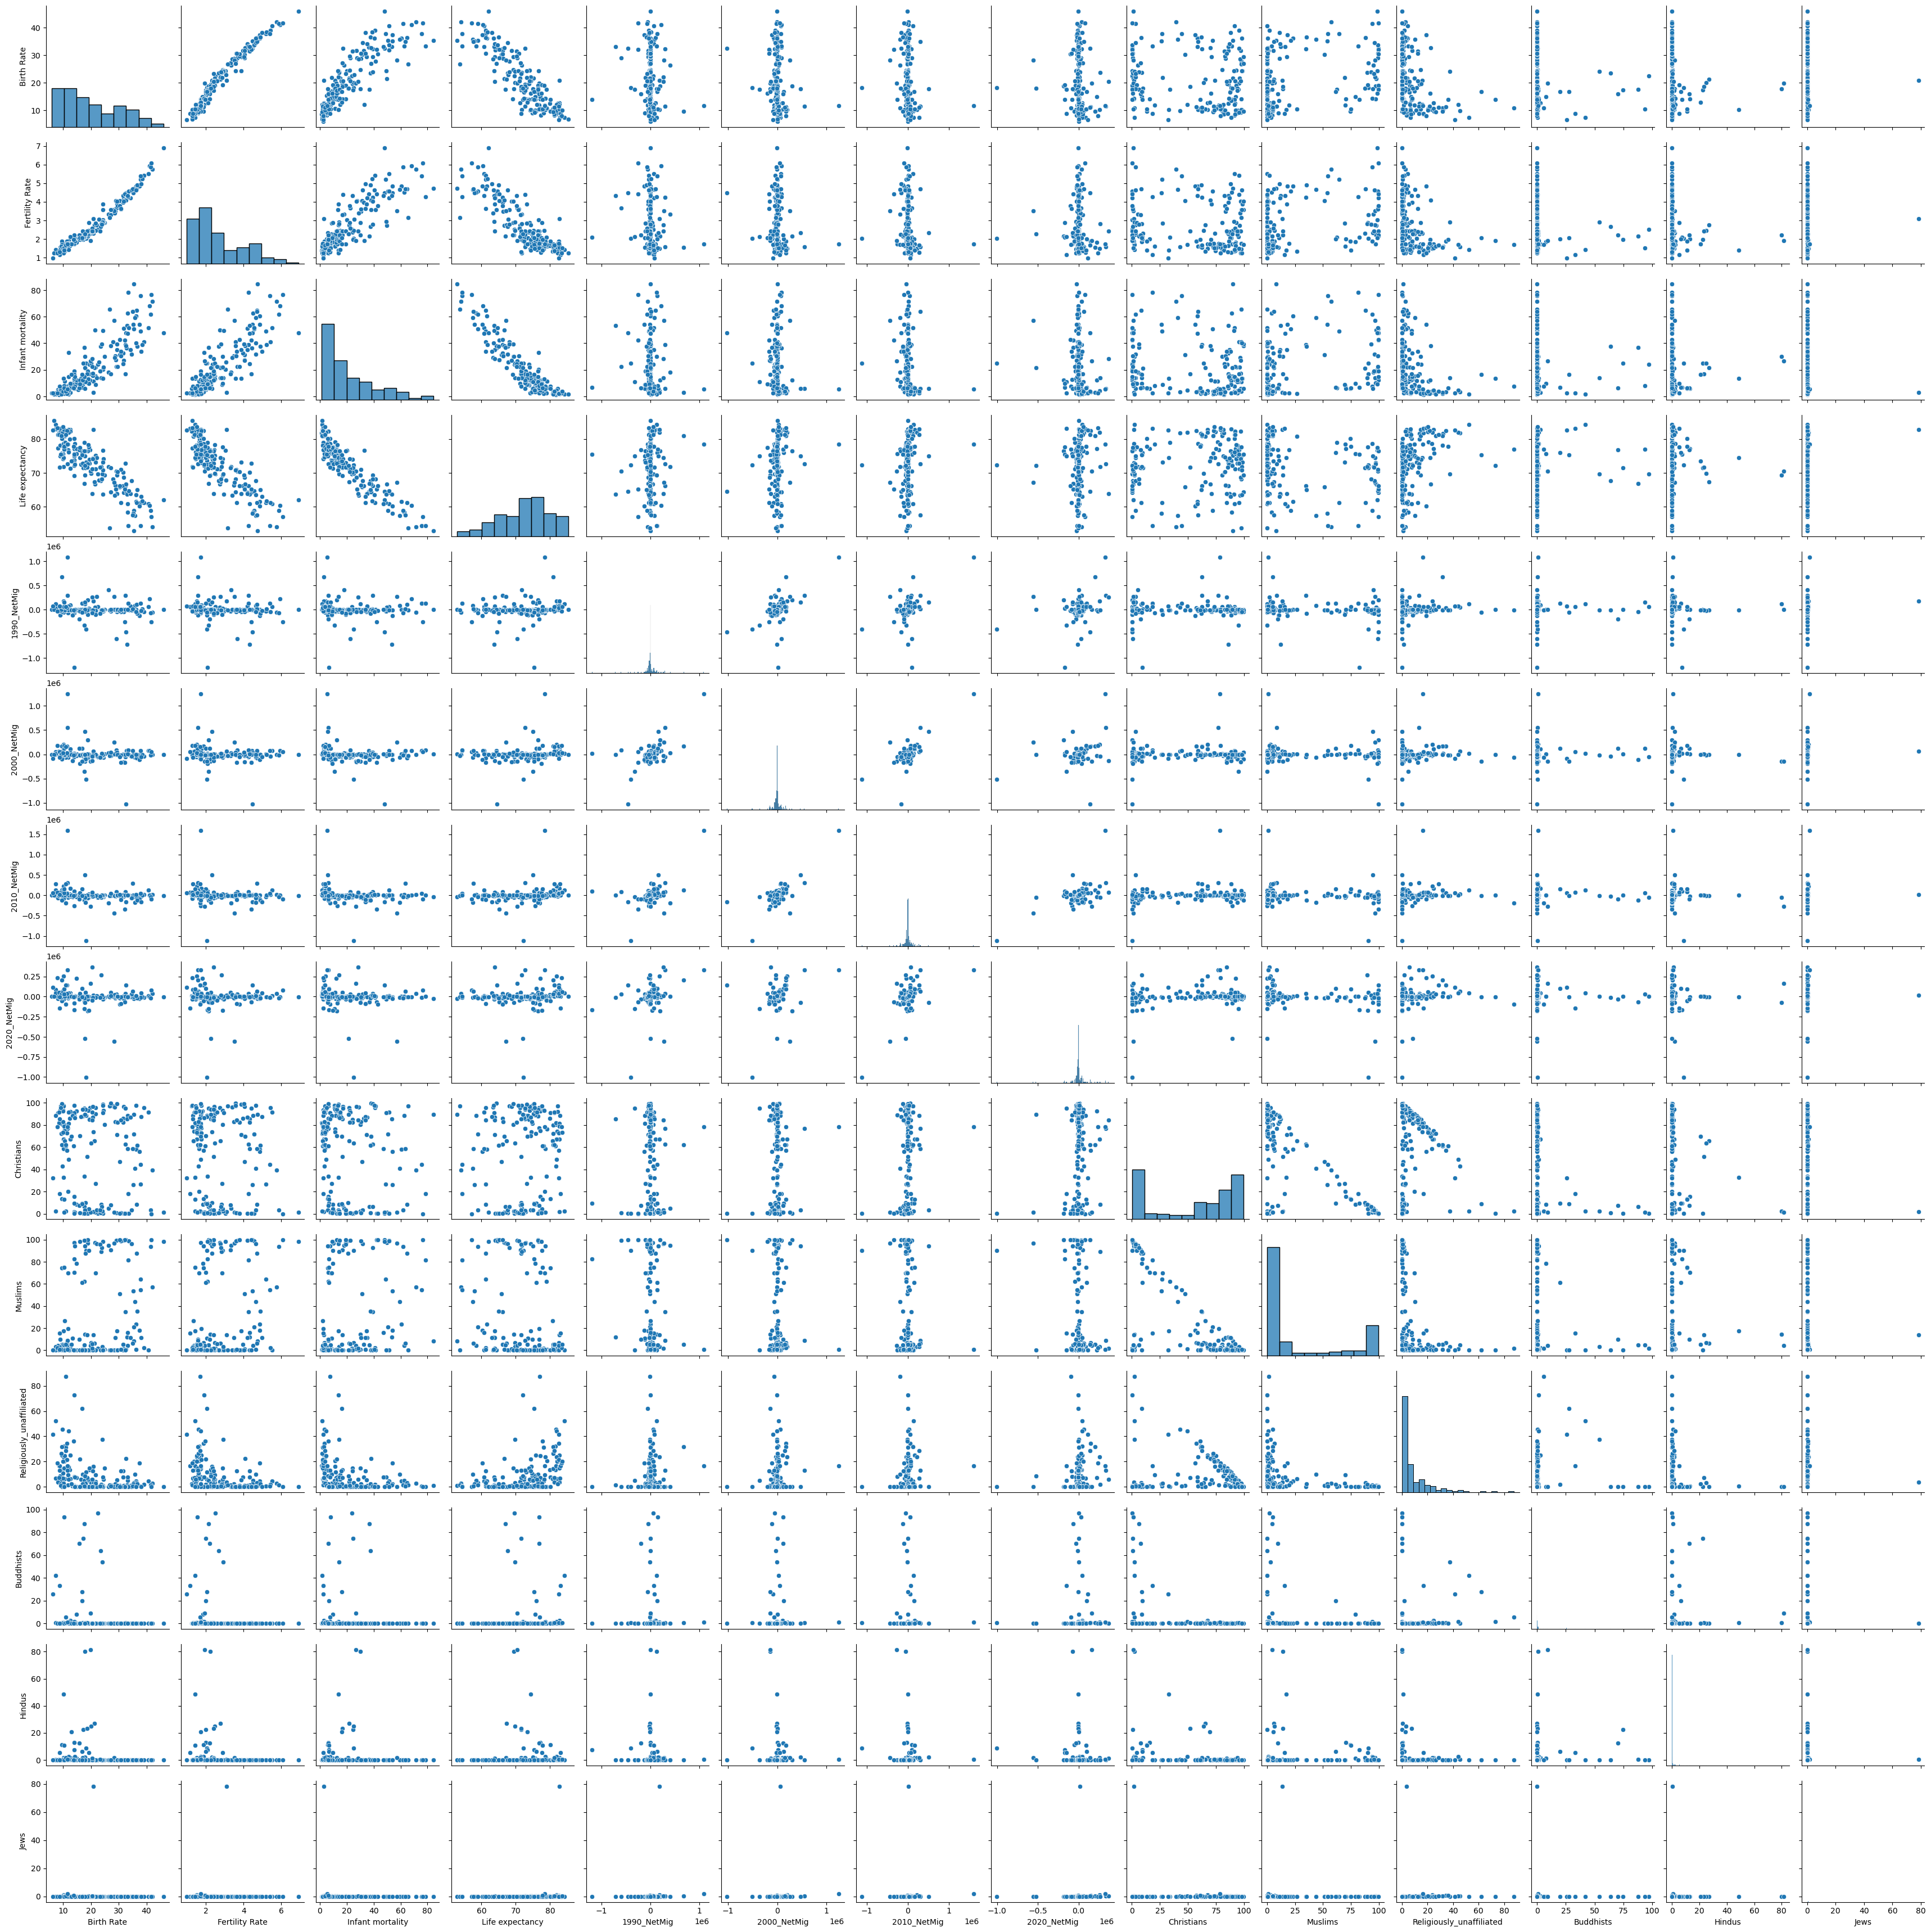

In [42]:
sns.pairplot(countries_df_subset[['Density\n(P/Km2)','Agricultural Land( %)','Land Area(Km2)','Armed Forces size','Birth Rate', 'Co2-Emissions','CPI',
                     'CPI Change (%)','Fertility Rate','Forested Area (%)','Gasoline Price','GDP','Gross primary education enrollment (%)',
                     'Gross tertiary education enrollment (%)','Infant mortality', 'Life expectancy', '1990_NetMig','2000_NetMig','2010_NetMig','2020_NetMig',
                      'Christians','Muslims','Religiously_unaffiliated','Buddhists','Hindus','Jews']])


Overview of Combined Data: Identifying NAs

In [43]:
countries_df.isna().sum()

Country                                0
Density\n(P/Km2)                       0
Abbreviation                           7
Agricultural Land( %)                  7
Land Area(Km2)                         1
                                      ..
Social support_2019                   52
Health (Life Expectancy)_2019         52
Freedom_2019                          52
Generosity_2019                       52
Trust (Government Corruption)_2019    52
Length: 164, dtype: int64

In [44]:
countries_df_nona = countries_df[-countries_df.isna().any(axis = 1)]

In [45]:
countries_df_nona = countries_df_nona.drop(countries_df_nona.columns[36:101], axis = 1)

In [190]:
countries_df_nona.to_csv('test_model_df.csv', index = False)

'NetMigSince1960'

In [51]:
X = X.drop(['Currency-Code'], axis = 1)

In [52]:
X.describe(include = "all")

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Hindus,Jews,Other_religions,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
count,95,95,95,95,95.000000,95.000000,95,95,95,95.000000,...,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
unique,78,90,95,76,NaN,NaN,95,95,58,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,83,64.80%,"652,230","9,000",NaN,NaN,"8,672",149.9,0.70%,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,2,1,4,NaN,NaN,1,1,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,19.330316,333.147368,NaN,NaN,NaN,2.552526,...,2.742472,0.913906,1.658015,5.425589,0.923505,1.211716,0.744484,0.389621,0.175800,0.091211
std,NaN,NaN,NaN,NaN,9.725668,347.821945,NaN,NaN,NaN,1.247711,...,12.644703,8.048507,2.806924,0.989631,0.342559,0.285153,0.209186,0.131460,0.101485,0.072873
min,NaN,NaN,NaN,NaN,6.400000,1.000000,NaN,NaN,NaN,0.980000,...,0.000000,0.000000,0.000000,3.203000,0.138000,0.378000,0.232000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,10.900000,63.500000,NaN,NaN,NaN,1.625000,...,0.001347,0.000254,0.114118,4.654500,0.681000,1.057000,0.584500,0.310000,0.101000,0.040500
50%,NaN,NaN,NaN,NaN,17.550000,232.000000,NaN,NaN,NaN,2.090000,...,0.009422,0.007316,0.592142,5.425000,1.002000,1.269000,0.808000,0.418000,0.166000,0.078000
75%,NaN,NaN,NaN,NaN,24.690000,383.000000,NaN,NaN,NaN,3.055000,...,0.098409,0.047699,2.021979,6.111500,1.185000,1.446500,0.874000,0.495000,0.239500,0.113500


In [60]:
X.loc[:, 'Density\n(P/Km2)'] = X['Density\n(P/Km2)'].apply(strnum_to_int)
X.loc[:, 'Land Area(Km2)'] = X['Land Area(Km2)'].apply(strnum_to_int)
X.loc[:, 'Armed Forces size'] = X['Armed Forces size'].apply(strnum_to_int)
X.loc[:, 'Co2-Emissions'] = X['Co2-Emissions'].apply(strnum_to_int)


In [54]:
X.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Hindus,Jews,Other_religions,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
0,60,58.10%,652230,323000,32.49,93.0,8672,149.9,2.30%,4.47,...,0.000355,0.000106,0.121495,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,105,43.10%,28748,9000,11.78,355.0,4536,119.05,1.40%,1.62,...,0.000000,0.009594,0.016603,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,18,17.40%,2381741,317000,24.28,213.0,150006,151.36,2.00%,3.02,...,0.000000,0.000152,0.038876,5.211,1.002,1.160,0.785,0.086,0.073,0.114
6,17,54.30%,2780400,105000,17.02,54.0,201348,232.75,53.50%,2.26,...,0.002482,0.442821,0.727031,6.086,1.092,1.432,0.881,0.471,0.066,0.050
7,104,58.90%,29743,49000,13.99,374.0,5156,129.18,1.40%,1.76,...,0.004752,0.003394,1.222922,4.559,0.850,1.055,0.815,0.283,0.095,0.064


In [61]:
X.describe(include = 'all')

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Hindus,Jews,Other_religions,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
count,95,95,95,95,95.000000,95.000000,95,95,95,95.000000,...,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
unique,78,90,95,76,NaN,NaN,95,95,58,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,83,64.80%,652230,9000,NaN,NaN,8672,149.9,0.70%,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,2,1,4,NaN,NaN,1,1,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,19.330316,333.147368,NaN,NaN,NaN,2.552526,...,2.742472,0.913906,1.658015,5.425589,0.923505,1.211716,0.744484,0.389621,0.175800,0.091211
std,NaN,NaN,NaN,NaN,9.725668,347.821945,NaN,NaN,NaN,1.247711,...,12.644703,8.048507,2.806924,0.989631,0.342559,0.285153,0.209186,0.131460,0.101485,0.072873
min,NaN,NaN,NaN,NaN,6.400000,1.000000,NaN,NaN,NaN,0.980000,...,0.000000,0.000000,0.000000,3.203000,0.138000,0.378000,0.232000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,10.900000,63.500000,NaN,NaN,NaN,1.625000,...,0.001347,0.000254,0.114118,4.654500,0.681000,1.057000,0.584500,0.310000,0.101000,0.040500
50%,NaN,NaN,NaN,NaN,17.550000,232.000000,NaN,NaN,NaN,2.090000,...,0.009422,0.007316,0.592142,5.425000,1.002000,1.269000,0.808000,0.418000,0.166000,0.078000
75%,NaN,NaN,NaN,NaN,24.690000,383.000000,NaN,NaN,NaN,3.055000,...,0.098409,0.047699,2.021979,6.111500,1.185000,1.446500,0.874000,0.495000,0.239500,0.113500


In [151]:
y = countries_df_nona[["NetMigSince1960"]]
y.head()

,NetMigSince1960
0,-5046170.0
1,-1475018.0
2,-212779.0
6,514109.0
7,-881928.0


In [72]:
X.shape

(95, 45)

(95, 45)

In [ ]:
X = X.dropna(how = "all")

In [79]:
X.columns

Index(['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
       'Armed Forces size', 'Birth Rate', 'Calling Code', 'Co2-Emissions',
       'CPI', 'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Life expectancy', 'Maternal mortality ratio', 'Minimum wage',
       'Out of pocket health expenditure', 'Physicians per thousand',
       'Population_x', 'Population: Labor force participation (%)',
       'Tax revenue (%)', 'Total tax rate', 'Unemployment rate',
       'Urban_population', 'Latitude', 'Longitude', 'Year', 'Population_y',
       'Christians', 'Muslims', 'Religiously_unaffiliated', 'Buddhists',
       'Hindus', 'Jews', 'Other_religions', 'Happiness Score_2019',
       'Economy (GDP per Capita)_2019', 'Social support_2019',
       'Health (Life Expectancy)_2019', 'Freedom_2019', 'Generosity_2019',
       'Trus

In [82]:
X_num = X.select_dtypes(include = np.number)


In [ ]:
lm_model = LinearRegression()

In [85]:
lm_model.fit(X_num, y)

LinearRegression()

array([[ 1.90068059e+05, -2.66669640e+03,  2.07393719e+06,
        -3.54364256e+05, -6.11646397e+05,  8.53158442e+03,
         1.10623809e+06,  9.15141848e+03, -5.73981424e+04,
        -1.10933196e+01, -5.01817587e-03, -3.85206330e+11,
        -3.85206306e+11, -3.85206245e+11, -3.85206313e+11,
        -3.85206289e+11, -3.85206422e+11, -3.85205997e+11,
         3.60026361e+05,  1.81640851e+07, -3.39072708e+06,
         2.75594726e+06, -7.85322429e+06,  4.09874868e+07,
        -9.41884520e+06]])

In [95]:
y_pred = lm_model.predict(X_num)

In-Sample R Squared Value

In [96]:
r2_score(y, y_pred)

0.40298274171866943

What are the most important coefficients?

In [97]:
lm_model.coef_

array([[ 1.90068059e+05, -2.66669640e+03,  2.07393719e+06,
        -3.54364256e+05, -6.11646397e+05,  8.53158442e+03,
         1.10623809e+06,  9.15141848e+03, -5.73981424e+04,
        -1.10933196e+01, -5.01817587e-03, -3.85206330e+11,
        -3.85206306e+11, -3.85206245e+11, -3.85206313e+11,
        -3.85206289e+11, -3.85206422e+11, -3.85205997e+11,
         3.60026361e+05,  1.81640851e+07, -3.39072708e+06,
         2.75594726e+06, -7.85322429e+06,  4.09874868e+07,
        -9.41884520e+06]])

In [110]:
list(X_num.columns)

['Birth Rate',
 'Calling Code',
 'Fertility Rate',
 'Infant mortality',
 'Life expectancy',
 'Maternal mortality ratio',
 'Physicians per thousand',
 'Latitude',
 'Longitude',
 'Year',
 'Population_y',
 'Christians',
 'Muslims',
 'Religiously_unaffiliated',
 'Buddhists',
 'Hindus',
 'Jews',
 'Other_religions',
 'Happiness Score_2019',
 'Economy (GDP per Capita)_2019',
 'Social support_2019',
 'Health (Life Expectancy)_2019',
 'Freedom_2019',
 'Generosity_2019',
 'Trust (Government Corruption)_2019']

In [118]:
names_list = list(X_num.columns)
coef_list = lm_model.coef_

list(coef_list)

[array([ 1.90068059e+05, -2.66669640e+03,  2.07393719e+06, -3.54364256e+05,
        -6.11646397e+05,  8.53158442e+03,  1.10623809e+06,  9.15141848e+03,
        -5.73981424e+04, -1.10933196e+01, -5.01817587e-03, -3.85206330e+11,
        -3.85206306e+11, -3.85206245e+11, -3.85206313e+11, -3.85206289e+11,
        -3.85206422e+11, -3.85205997e+11,  3.60026361e+05,  1.81640851e+07,
        -3.39072708e+06,  2.75594726e+06, -7.85322429e+06,  4.09874868e+07,
        -9.41884520e+06])]

In [126]:
len(names_list)
len([lm_model.intercept_] + list(coef_list))

2

In [127]:
[lm_model.intercept_] + list(coef_list)

[array([3.85206522e+13]),
 array([ 1.90068059e+05, -2.66669640e+03,  2.07393719e+06, -3.54364256e+05,
        -6.11646397e+05,  8.53158442e+03,  1.10623809e+06,  9.15141848e+03,
        -5.73981424e+04, -1.10933196e+01, -5.01817587e-03, -3.85206330e+11,
        -3.85206306e+11, -3.85206245e+11, -3.85206313e+11, -3.85206289e+11,
        -3.85206422e+11, -3.85205997e+11,  3.60026361e+05,  1.81640851e+07,
        -3.39072708e+06,  2.75594726e+06, -7.85322429e+06,  4.09874868e+07,
        -9.41884520e+06])]

In [135]:
len(lm_model.coef_.ravel().tolist())

25

In [136]:
lm_coef = pd.DataFrame({'names': list(X_num.columns), 'coef': lm_model.coef_.ravel().tolist()})

In [137]:
lm_coef

,names,coef
0,Birth Rate,1.900681e+05
1,Calling Code,-2.666696e+03
2,Fertility Rate,2.073937e+06
3,Infant mortality,-3.543643e+05
4,Life expectancy,-6.116464e+05
5,Maternal mortality ratio,8.531584e+03
6,Physicians per thousand,1.106238e+06
7,Latitude,9.151418e+03
8,Longitude,-5.739814e+04
9,Year,-1.109332e+01


In [191]:
lm_model.rank_

24

In [139]:
lm_model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Principal Component Analysis

Principal Component Analysis

Principal Component Analysis

In [141]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

In [143]:
pca_X_num = PCA(n_components = 2)
pca_X_num.fit(X_scaled)

PCA(n_components=2)

In [144]:
principal_components = pca_X_num.fit_transform(X_num)

In [145]:
pca_df = pd.DataFrame(data = principal_components,
                      columns = ["PC1", "PC2"])

In [147]:
X_num

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude,Year,...,Hindus,Jews,Other_religions,Happiness Score_2019,Economy (GDP per Capita)_2019,Social support_2019,Health (Life Expectancy)_2019,Freedom_2019,Generosity_2019,Trust (Government Corruption)_2019
0,32.49,93.0,4.47,47.9,64.5,638.0,0.28,33.939110,67.709953,2010.0,...,0.000355,0.000106,0.121495,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,11.78,355.0,1.62,7.8,78.5,15.0,1.20,41.153332,20.168331,2010.0,...,0.000000,0.009594,0.016603,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,24.28,213.0,3.02,20.1,76.7,112.0,1.72,28.033886,1.659626,2010.0,...,0.000000,0.000152,0.038876,5.211,1.002,1.160,0.785,0.086,0.073,0.114
6,17.02,54.0,2.26,8.8,76.5,39.0,3.96,-38.416097,-63.616672,2010.0,...,0.002482,0.442821,0.727031,6.086,1.092,1.432,0.881,0.471,0.066,0.050
7,13.99,374.0,1.76,11.0,74.9,26.0,4.40,40.069099,45.038189,2010.0,...,0.004752,0.003394,1.222922,4.559,0.850,1.055,0.815,0.283,0.095,0.064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,11.00,44.0,1.68,3.6,81.3,7.0,2.81,55.378051,-3.435973,2010.0,...,1.470572,0.451687,1.207052,7.054,1.333,1.538,0.996,0.450,0.348,0.278
187,11.60,1.0,1.73,5.6,78.5,19.0,2.61,37.090240,-95.712891,2010.0,...,0.575295,1.834127,0.813565,6.892,1.433,1.457,0.874,0.454,0.280,0.128
188,13.86,598.0,1.97,6.4,77.8,17.0,5.05,-32.522779,-55.765835,2010.0,...,0.000000,0.518992,2.216484,6.293,1.124,1.465,0.891,0.523,0.127,0.150
192,16.75,84.0,2.05,16.5,75.3,43.0,0.82,14.058324,108.277199,2010.0,...,0.065549,0.000143,1.320780,5.175,0.741,1.346,0.851,0.543,0.147,0.073


In [146]:
pca_df

,PC1,PC2
0,-3.459771e+07,-300.324646
1,-5.995307e+07,16.260814
2,-2.669356e+07,-123.103710
3,-2.159310e+07,-277.710439
4,-5.995072e+07,30.279469
...,...,...
90,1.246874e+05,-274.698564
91,2.481810e+08,-237.528594
92,-5.956322e+07,253.223637
93,2.457336e+07,-229.158718


In [154]:
X.columns

Index(['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
       'Armed Forces size', 'Birth Rate', 'Calling Code', 'Co2-Emissions',
       'CPI', 'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Life expectancy', 'Maternal mortality ratio', 'Minimum wage',
       'Out of pocket health expenditure', 'Physicians per thousand',
       'Population_x', 'Population: Labor force participation (%)',
       'Tax revenue (%)', 'Total tax rate', 'Unemployment rate',
       'Urban_population', 'Latitude', 'Longitude', 'Year', 'Population_y',
       'Christians', 'Muslims', 'Religiously_unaffiliated', 'Buddhists',
       'Hindus', 'Jews', 'Other_religions', 'Happiness Score_2019',
       'Economy (GDP per Capita)_2019', 'Social support_2019',
       'Health (Life Expectancy)_2019', 'Freedom_2019', 'Generosity_2019',
       'Trus

0         Afghanistan
1             Albania
2             Algeria
6           Argentina
7             Armenia
            ...      
186    United Kingdom
187     United States
188           Uruguay
192           Vietnam
194            Zambia
Name: Country, Length: 95, dtype: object

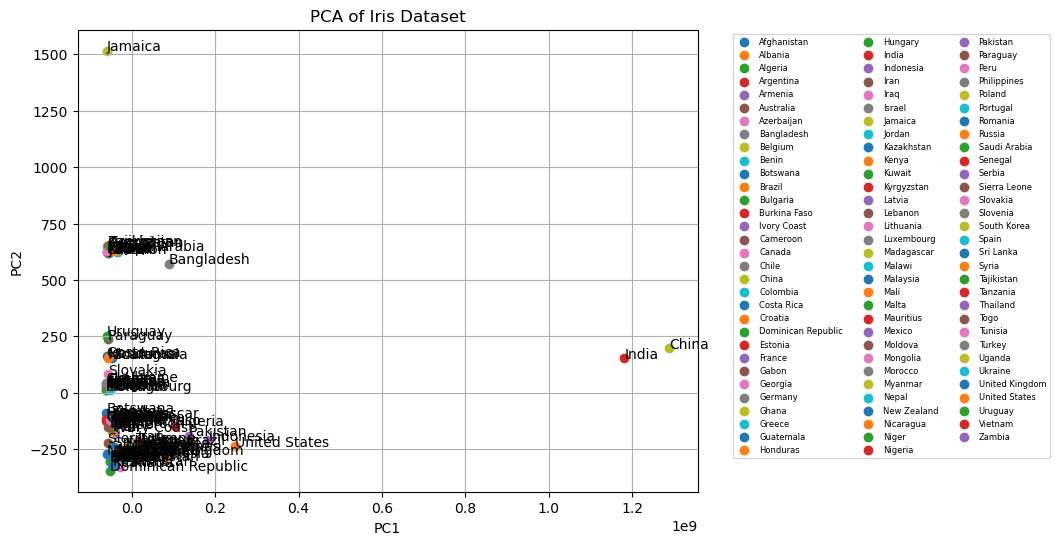

In [185]:
pca_df['NetMig'] = y
plt.figure(figsize=(8, 6))
target_names = countries_df_nona.Country

# Plot the data points colored by their original class
for i, target_name in enumerate(target_names):
    plt.scatter(pca_df.loc[i, 'PC1'],
                pca_df.loc[i, 'PC2'],
                label=target_name)
    plt.text(x = pca_df_2.loc[i, 'PC1'], 
             y = pca_df_2.loc[i, 'PC2'], s = target_name)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
plt.legend(loc = "upper left", bbox_to_anchor=(1.05, 1), fontsize = 6,
           ncol = 3)
plt.grid(True)
plt.show()

In [169]:
for i, target_name in enumerate(target_names):
    #print(i, target_name)
    #print(pca_df['NetMig'] == i)
    print(pca_df.loc[i, 'PC1'])
    print(pca_df.loc[i, 'PC2'])

-34597707.05255412
-300.32464570972195
-59953074.05263204
16.26081377927758
-26693560.05258881
-123.10371008275499
-21593102.05254035
-277.71043901600814
-59950717.55264012
30.279469354946414
-40740215.05252809
-271.328482941697
-53734945.05284736
653.3694395811548
89320185.94718237
572.1903259235619
-51945170.052524276
-303.7259677386619
-53084311.5525998
-150.16681345397876
-60848685.052606374
-89.37159749738326
130820133.94745037
-227.8939382292963
-55444197.05263545
19.148530086910753
-46705297.552597076
-140.87468651870407
-40393731.05260324
-172.37800406136094
-43213729.55260565
-153.2550821385993
-28684897.0525222
-328.3075198118252
-45700331.5525393
-280.99336279300564
1288679718.4473848
195.81983423738754
-18104476.552543107
-277.9996534317493
-58325833.55269215
160.67460707773333
-58580650.05264515
43.56731170391313
-53061620.55252146
-346.24584453654876
-61550347.052637875
30.58520508427922
535566.9474720359
-285.49813747412077
-61161916.552600995
-126.66165440215923
-589858

In [167]:
pca_df

,PC1,PC2,NetMig
0,-3.459771e+07,-300.324646,-5046170.0
1,-5.995307e+07,16.260814,-1475018.0
2,-2.669356e+07,-123.103710,-212779.0
3,-2.159310e+07,-277.710439,NaN
4,-5.995072e+07,30.279469,NaN
...,...,...,...
90,1.246874e+05,-274.698564,NaN
91,2.481810e+08,-237.528594,2107880.0
92,-5.956322e+07,253.223637,-589670.0
93,2.457336e+07,-229.158718,NaN


In [179]:
pca_X_num = PCA(n_components = 4)
pca_X_num.fit(X_scaled)
principal_components_2 = pca_X_num.fit_transform(X_num)
pca_df_2 = pd.DataFrame(data = principal_components_2,
                      columns = ["PC1", "PC2", "PC3", "PC4"])

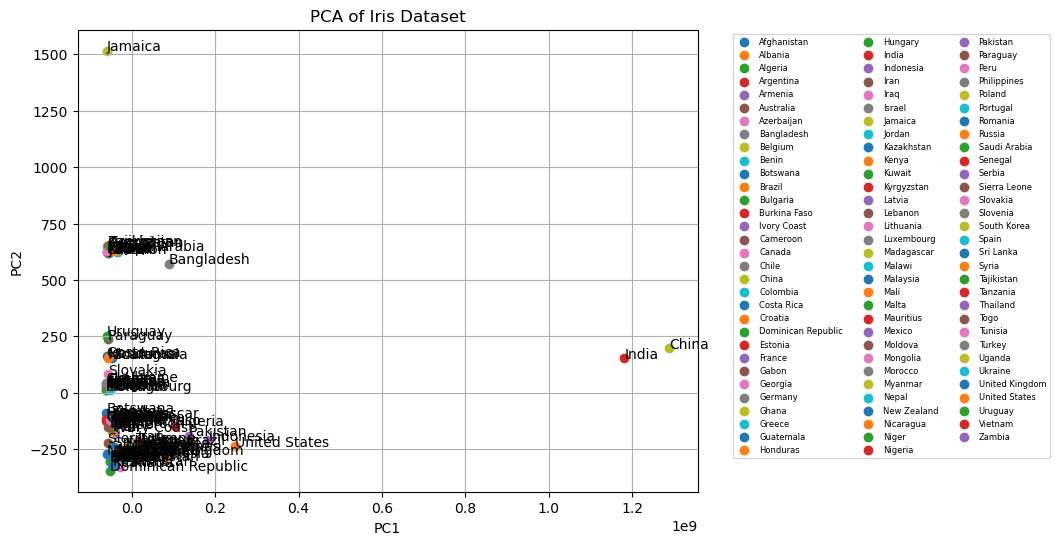

In [184]:
pca_df_2['NetMig'] = y
plt.figure(figsize=(8, 6))
target_names = countries_df_nona.Country

# Plot the data points colored by their original class
for i, target_name in enumerate(target_names):
    plt.scatter(pca_df_2.loc[i, 'PC1'],
                pca_df_2.loc[i, 'PC2'],
                label=target_name)
    plt.text(x = pca_df_2.loc[i, 'PC1'], 
             y = pca_df_2.loc[i, 'PC2'], s = target_name)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
plt.legend(loc = "upper left", bbox_to_anchor=(1.05, 1), fontsize = 6,
           ncol = 3)
plt.grid(True)
plt.show()

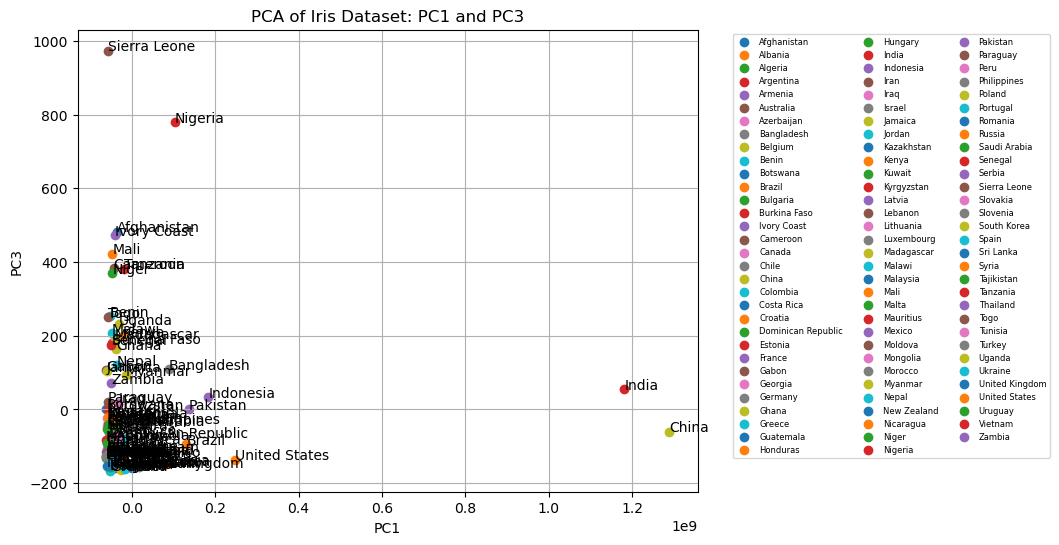

In [ ]:
plt.figure(figsize=(8, 6))
target_names = countries_df_nona.Country

# Plot the data points colored by their original class
for i, target_name in enumerate(target_names):
    plt.scatter(pca_df_2.loc[i, 'PC1'],
                pca_df_2.loc[i, 'PC3'],
                label=target_name)
    plt.text(x = pca_df_2.loc[i, 'PC1'], 
             y = pca_df_2.loc[i, 'PC3'], s = target_name)

plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('PCA of Iris Dataset: PC1 and PC3')
plt.legend(loc = "upper left", bbox_to_anchor=(1.05, 1), fontsize = 6,
           ncol = 3)
plt.grid(True)
plt.show()

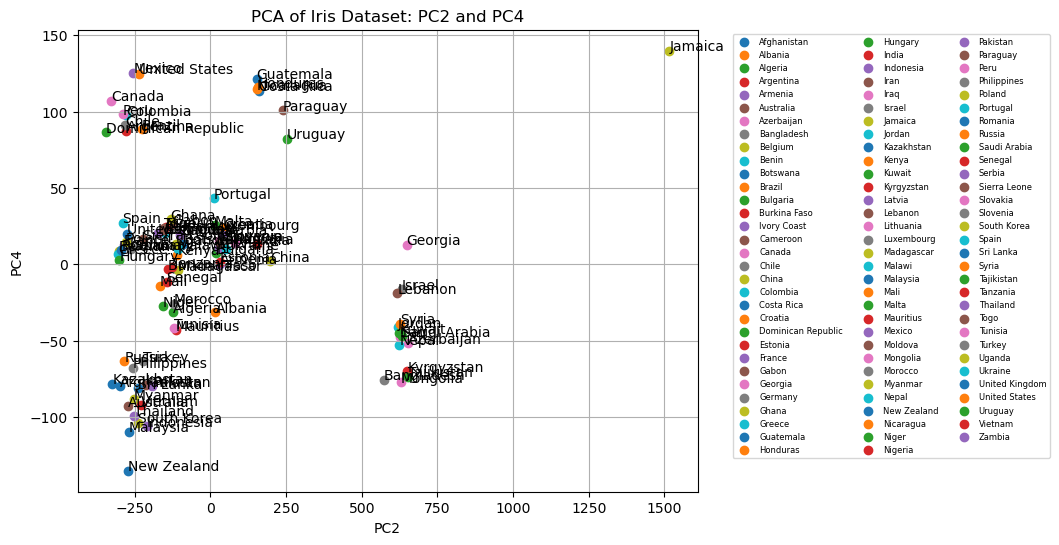

In [187]:
plt.figure(figsize=(8, 6))
target_names = countries_df_nona.Country

# Plot the data points colored by their original class
for i, target_name in enumerate(target_names):
    plt.scatter(pca_df_2.loc[i, 'PC2'],
                pca_df_2.loc[i, 'PC4'],
                label=target_name)
    plt.text(x = pca_df_2.loc[i, 'PC2'], 
             y = pca_df_2.loc[i, 'PC4'], s = target_name)

plt.xlabel('PC2')
plt.ylabel('PC4')
plt.title('PCA of Iris Dataset: PC2 and PC4')
plt.legend(loc = "upper left", bbox_to_anchor=(1.05, 1), fontsize = 6,
           ncol = 3)
plt.grid(True)
plt.show()

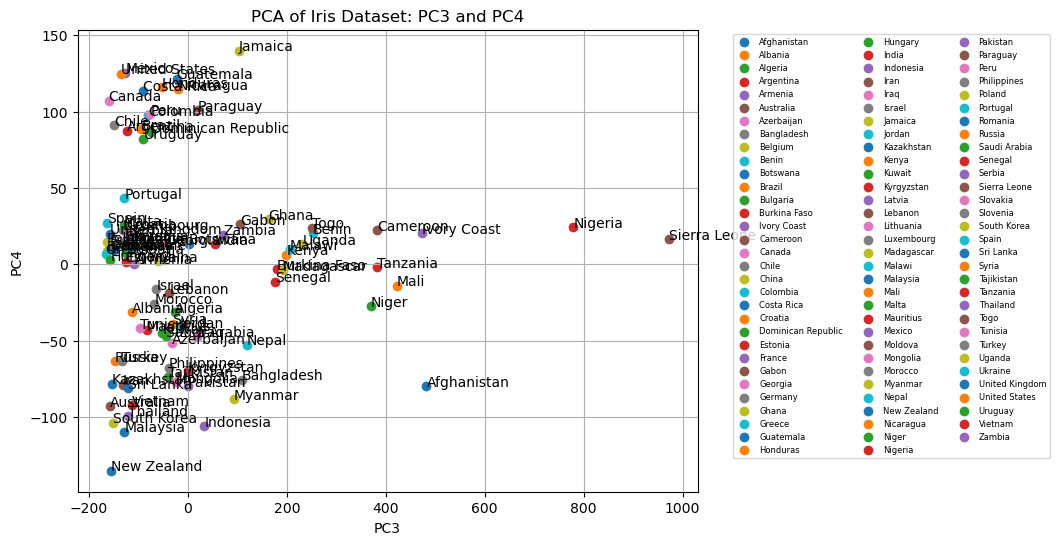

In [188]:
plt.figure(figsize=(8, 6))
target_names = countries_df_nona.Country

# Plot the data points colored by their original class
for i, target_name in enumerate(target_names):
    plt.scatter(pca_df_2.loc[i, 'PC3'],
                pca_df_2.loc[i, 'PC4'],
                label=target_name)
    plt.text(x = pca_df_2.loc[i, 'PC3'], 
             y = pca_df_2.loc[i, 'PC4'], s = target_name)

plt.xlabel('PC3')
plt.ylabel('PC4')
plt.title('PCA of Iris Dataset: PC3 and PC4')
plt.legend(loc = "upper left", bbox_to_anchor=(1.05, 1), fontsize = 6,
           ncol = 3)
plt.grid(True)
plt.show()